In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
os.makedirs("saved_models", exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
import joblib
import pprint
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna
import lightgbm as lgb
from catboost import CatBoostRegressor
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [3]:
def metrics_dict(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "R2": r2_score(y_true, y_pred)
    }

def plot_series(title, y_true, y_pred, start=0, end=None, figsize=(14,4)):
    plt.figure(figsize=figsize)
    plt.plot(np.arange(start, start + len(y_true)), y_true, label="Actual", linewidth=2)
    plt.plot(np.arange(start, start + len(y_pred)), y_pred, label="Pred", alpha=0.9)
    plt.title(title)
    plt.legend(); plt.grid(True); plt.show()

def model_diagnostics(name, y_true, y_pred, test_df):
    print(f"\n=== Diagnostics: {name} ===")
    print("Overall:", metrics_dict(y_true, y_pred))
    if "festival_flag" in test_df.columns:
        mask = test_df["festival_flag"].values.astype(bool)
        if mask.sum()>0:
            print("Festival days:", metrics_dict(y_true[mask], y_pred[mask]))
            plot_series(f"{name} - Festival days", y_true[mask], y_pred[mask])
    if "is_weekend" in test_df.columns:
        mask = test_df["is_weekend"].values==1
        if mask.sum()>0:
            print("Weekend days:", metrics_dict(y_true[mask], y_pred[mask]))
            plot_series(f"{name} - Weekend days", y_true[mask], y_pred[mask])
    mask = np.ones(len(test_df), dtype=bool)
    if "festival_flag" in test_df.columns:
        mask &= (test_df["festival_flag"].values==0)
    if "public_holiday" in test_df.columns:
        mask &= (test_df["public_holiday"].values==0)
    if mask.sum()>0:
        print("Normal days:", metrics_dict(y_true[mask], y_pred[mask]))


In [4]:
DATA_PATH = "test.csv" 
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
df = df.sort_values('date').reset_index(drop=True)
print("Loaded", df.shape)
display(df.head())

Loaded (3653, 10)


,date,temple_name,day_of_week,is_weekend,festival_flag,festival_name,public_holiday,temp_avg_c,precipitation_mm,visitor_count
0,2016-01-01,Ambaji,4,0,0,NaN,0,21.89,0.16,39742
1,2016-01-02,Ambaji,5,1,0,NaN,0,21.75,0.52,49176
2,2016-01-03,Ambaji,6,1,0,NaN,0,20.74,0.79,39807
3,2016-01-04,Ambaji,0,0,0,NaN,0,22.01,0.67,36798
4,2016-01-05,Ambaji,1,0,0,NaN,0,21.78,0.85,39638


In [5]:
df.columns

Index(['date', 'temple_name', 'day_of_week', 'is_weekend', 'festival_flag',
       'festival_name', 'public_holiday', 'temp_avg_c', 'precipitation_mm',
       'visitor_count'],
      dtype='object')

In [6]:
festival_encoding = {
    "None": 0,
    "Diwali": 1,
    "Holi": 2,
    "Janmashtami": 3,
    "Makar Sakranti": 4,
    "MahaShivratri": 5,
    "Navratri": 6
}
df["festival_name"] = df["festival_name"].fillna("None").astype(str)
df["festival_name"] = df["festival_name"].map(festival_encoding)
df["festival_name"] = df["festival_name"].fillna(0).astype(int)
df.to_csv("test_clean_encoded_2.csv", index=False)

In [7]:
TARGET = "visitor_count"
df["day_of_week"] = df["date"].dt.weekday
df["month"] = df["date"].dt.month  
df["day_of_year"] = df["date"].dt.dayofyear
df["year"] = df["date"].dt.year
df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
df["sin_dow"] = np.sin(2*np.pi * df["day_of_week"]/7)
df["cos_dow"] = np.cos(2*np.pi * df["day_of_week"]/7)
df["sin_month"] = np.sin(2*np.pi * df["month"]/12)
df["cos_month"] = np.cos(2*np.pi * df["month"]/12)
df["sin_year"] = np.sin(2*np.pi * df["day_of_year"]/365.25)
df["cos_year"] = np.cos(2*np.pi * df["day_of_year"]/365.25)
for lag in [1,2,3,7,14,30,60]:
    df[f"lag_{lag}"] = df[TARGET].shift(lag)
for win in [7,14,30]:
    df[f"roll_mean_{win}"] = df[TARGET].shift(1).rolling(win).mean()
    df[f"roll_std_{win}"] = df[TARGET].shift(1).rolling(win).std()
df["ema_7"] = df[TARGET].shift(1).ewm(span=7).mean()
df["ema_30"] = df[TARGET].shift(1).ewm(span=30).mean()
df = df.dropna().reset_index(drop=True)
print("After FE shape:", df.shape)

After FE shape: (3593, 35)


In [8]:
df

,date,temple_name,day_of_week,is_weekend,festival_flag,festival_name,public_holiday,temp_avg_c,precipitation_mm,visitor_count,...,lag_30,lag_60,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_30,roll_std_30,ema_7,ema_30
0,2016-03-01,Ambaji,1,0,0,0,0,27.33,0.25,35444,...,45690.0,39742.0,36867.285714,9449.177613,35226.000000,8589.425789,38693.966667,16611.156126,36351.147078,37416.050408
1,2016-03-02,Ambaji,2,0,0,0,0,27.92,0.82,37019,...,25534.0,49176.0,37425.142857,9194.005537,35638.071429,8439.712641,38352.433333,16567.628571,36124.360303,37286.606749
2,2016-03-03,Ambaji,3,0,0,0,0,27.57,0.25,47191,...,34240.0,39807.0,36424.714286,8725.621787,36518.714286,7830.723480,38735.266667,16392.988564,36348.020231,37269.060980
3,2016-03-04,Ambaji,4,0,0,0,0,27.66,0.58,38854,...,35579.0,36798.0,36336.714286,8593.807125,37727.285714,8093.576336,39166.966667,16440.984538,39058.765210,37918.915870
4,2016-03-05,Ambaji,5,1,0,0,0,28.04,0.25,51684,...,32167.0,39638.0,38432.285714,6721.281567,36975.000000,7385.008234,39276.133333,16427.206331,39007.573907,37980.100854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3588,2025-12-27,Ambaji,5,1,0,0,0,21.54,0.02,44487,...,47201.0,53717.0,47693.571429,4483.123199,48976.214286,4496.680505,49876.566667,6574.810361,46577.049127,50867.558068
3589,2025-12-28,Ambaji,6,1,0,0,0,22.81,0.07,41149,...,58743.0,45680.0,46688.142857,4264.512689,48382.214286,4501.545157,49786.100000,6631.323404,46054.536846,50455.909161
3590,2025-12-29,Ambaji,0,0,0,0,0,22.16,0.68,38355,...,57395.0,61201.0,45971.714286,4759.742630,47356.500000,4387.305740,49199.633333,6589.736526,44828.152634,49855.463408
3591,2025-12-30,Ambaji,1,0,0,0,0,20.97,0.63,43373,...,66108.0,63357.0,44274.571429,5092.602048,46336.285714,4713.245745,48564.966667,6689.343509,43209.864476,49113.498027


In [9]:
TEST_DAYS = 365
split_idx = len(df) - TEST_DAYS
train_df = df.iloc[:split_idx].copy().reset_index(drop=True)
test_df  = df.iloc[split_idx:].copy().reset_index(drop=True)
print("Train:", train_df.shape, "Test:", test_df.shape)

Train: (3228, 35) Test: (365, 35)


In [10]:
exclude = ["date", TARGET, "temple_name"] if "temple_name" in df.columns else ["date", TARGET]
feature_cols = [c for c in df.columns if c not in exclude]
X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET].copy()
X_test  = test_df[feature_cols].copy()
y_test  = test_df[TARGET].copy()
scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
scaler.fit(X_train[num_cols])
joblib.dump(scaler, "saved_models/scaler.pkl")
print("Num features:", len(feature_cols))

Num features: 32


In [11]:
def lgb_objective(trial):
    n_val = max(1, int(0.1 * len(X_train)))
    X_tr = X_train.iloc[:-n_val]
    y_tr = y_train.iloc[:-n_val]
    X_val = X_train.iloc[-n_val:]
    y_val = y_train.iloc[-n_val:]
    param = {
        "objective": "regression",
        "metric": "rmse",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "seed": RANDOM_SEED,
        "n_jobs": -1,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 31, 512),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 100),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 5.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 5.0),
        "max_bin": 255
    }
    model = lgb.LGBMRegressor(**param, n_estimators=5000)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    preds = model.predict(X_val)
    rmse = mean_squared_error(y_val, preds, squared=False)
    return rmse
lgb_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
lgb_study.optimize(lgb_objective, n_trials=25, show_progress_bar=True)
best_lgb_params = lgb_study.best_trial.params
print("Best LGB parameters:", best_lgb_params)

[I 2025-12-09 17:28:14,141] A new study created in memory with name: no-name-6d935838-f2e1-4bad-beec-e4eb8f2eaf23


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-12-09 17:28:19,176] Trial 0 finished with value: 8443.349228926141 and parameters: {'learning_rate': 0.015355286838886862, 'num_leaves': 489, 'min_data_in_leaf': 75, 'feature_fraction': 0.7993292420985183, 'bagging_fraction': 0.5780093202212182, 'lambda_l1': 0.7799726016810132, 'lambda_l2': 0.2904180608409973}. Best is trial 0 with value: 8443.349228926141.
[I 2025-12-09 17:28:20,587] Trial 1 finished with value: 8613.892356279532 and parameters: {'learning_rate': 0.06697167353375243, 'num_leaves': 320, 'min_data_in_leaf': 72, 'feature_fraction': 0.5102922471479012, 'bagging_fraction': 0.9849549260809971, 'lambda_l1': 4.162213204002109, 'lambda_l2': 1.0616955533913808}. Best is trial 0 with value: 8443.349228926141.
[I 2025-12-09 17:28:24,359] Trial 2 finished with value: 8046.109898874315 and parameters: {'learning_rate': 0.008620446097910767, 'num_leaves': 119, 'min_data_in_leaf': 34, 'feature_fraction': 0.762378215816119, 'bagging_fraction': 0.7159725093210578, 'lambda_l1': 

In [12]:
final_lgb = lgb.LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_estimators=5000,
    learning_rate=best_lgb_params["learning_rate"],
    num_leaves=int(best_lgb_params["num_leaves"]),
    min_data_in_leaf=int(best_lgb_params["min_data_in_leaf"]),
    feature_fraction=best_lgb_params["feature_fraction"],
    bagging_fraction=best_lgb_params["bagging_fraction"],
    lambda_l1=best_lgb_params["lambda_l1"],
    lambda_l2=best_lgb_params["lambda_l2"],
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
n_val = max(1, int(0.05 * len(X_train)))
X_tr_full = X_train.iloc[:-n_val]
y_tr_full = y_train.iloc[:-n_val]
X_val_full = X_train.iloc[-n_val:]
y_val_full = y_train.iloc[-n_val:]
callbacks = [
    lgb.early_stopping(stopping_rounds=100),
    lgb.log_evaluation(period=100)
]
final_lgb.fit(
    X_tr_full, y_tr_full,
    eval_set=[(X_val_full, y_val_full)],
    eval_metric="rmse",
    callbacks=callbacks
)
final_lgb.booster_.save_model("saved_models/lightgbm_model.txt")
joblib.dump(final_lgb, "saved_models/lgb_wrapper.pkl")

[LightGBM] [Warning] min_data_in_leaf is set=23, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=23
[LightGBM] [Warning] feature_fraction is set=0.6990364261577717, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6990364261577717
[LightGBM] [Warning] lambda_l1 is set=3.463151494965761, reg_alpha=0.0 will be ignored. Current value: lambda_l1=3.463151494965761
[LightGBM] [Warning] lambda_l2 is set=1.6629340870699119, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.6629340870699119
[LightGBM] [Warning] bagging_fraction is set=0.6194399565623017, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6194399565623017
[LightGBM] [Warning] min_data_in_leaf is set=23, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=23
[LightGBM] [Warning] feature_fraction is set=0.6990364261577717, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6990364261577717
[LightGBM] [Warning] lambda_l1 is se

['saved_models/lgb_wrapper.pkl']

In [13]:
def cat_objective(trial):
    n_val = max(1, int(0.1 * len(X_train)))
    X_tr = X_train.iloc[:-n_val]
    y_tr = y_train.iloc[:-n_val]
    X_val = X_train.iloc[-n_val:]
    y_val = y_train.iloc[-n_val:]
    param = {
        "iterations": trial.suggest_categorical("iterations", [500, 1000, 1500]),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "random_seed": RANDOM_SEED,
        "verbose": False
    }
    model = CatBoostRegressor(**param)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        use_best_model=True,
        early_stopping_rounds=100,
        verbose=False
    )
    preds = model.predict(X_val)
    rmse = mean_squared_error(y_val, preds, squared=False)
    return rmse
cat_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
cat_study.optimize(cat_objective, n_trials=25, show_progress_bar=True)
best_cat_params = cat_study.best_trial.params
print("Best CatBoost params:", best_cat_params)


[I 2025-12-09 17:29:01,165] A new study created in memory with name: no-name-e7c2c2d4-18b2-4440-8b20-8fcc923fb644


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-12-09 17:29:05,790] Trial 0 finished with value: 8126.239267239372 and parameters: {'iterations': 1000, 'depth': 8, 'learning_rate': 0.014322493718230255, 'l2_leaf_reg': 0.004207053950287938}. Best is trial 0 with value: 8126.239267239372.
[I 2025-12-09 17:29:10,397] Trial 1 finished with value: 8491.95066386406 and parameters: {'iterations': 1000, 'depth': 8, 'learning_rate': 0.010485387725194618, 'l2_leaf_reg': 7.579479953348009}. Best is trial 0 with value: 8126.239267239372.
[I 2025-12-09 17:29:11,137] Trial 2 finished with value: 7080.815604334863 and parameters: {'iterations': 500, 'depth': 5, 'learning_rate': 0.02014847788415866, 'l2_leaf_reg': 0.12561043700013558}. Best is trial 2 with value: 7080.815604334863.
[I 2025-12-09 17:29:12,453] Trial 3 finished with value: 6994.380668933693 and parameters: {'iterations': 1500, 'depth': 4, 'learning_rate': 0.019594972058679168, 'l2_leaf_reg': 0.029204338471814112}. Best is trial 3 with value: 6994.380668933693.
[I 2025-12-09 1

In [14]:
final_cat = CatBoostRegressor(
    iterations=int(best_cat_params.get("iterations", 1000)),
    depth=int(best_cat_params.get("depth", 6)),
    learning_rate=best_cat_params.get("learning_rate", 0.03),
    l2_leaf_reg=best_cat_params.get("l2_leaf_reg", 3.0),
    random_seed=RANDOM_SEED
)
n_val = max(1, int(0.05 * len(X_train)))
X_tr_full = X_train.iloc[:-n_val]; y_tr_full = y_train.iloc[:-n_val]
X_val_full = X_train.iloc[-n_val:]; y_val_full = y_train.iloc[-n_val:]
final_cat.fit(
    X_tr_full, y_tr_full,
    eval_set=(X_val_full, y_val_full),
    use_best_model=True,
    early_stopping_rounds=100
)
final_cat.save_model("saved_models/catboost_model.cbm")
joblib.dump(final_cat, "saved_models/cat_wrapper.pkl")

0:	learn: 23460.8952682	test: 38359.2371132	best: 38359.2371132 (0)	total: 1.56ms	remaining: 2.34s
1:	learn: 22673.8196966	test: 37236.3707791	best: 37236.3707791 (1)	total: 3.15ms	remaining: 2.36s
2:	learn: 21882.3378354	test: 36057.0125325	best: 36057.0125325 (2)	total: 5.67ms	remaining: 2.83s
3:	learn: 21137.6331136	test: 34954.2028647	best: 34954.2028647 (3)	total: 8.19ms	remaining: 3.06s
4:	learn: 20411.8812430	test: 33914.0255181	best: 33914.0255181 (4)	total: 10.2ms	remaining: 3.06s
5:	learn: 19747.3204611	test: 32862.5403949	best: 32862.5403949 (5)	total: 13.5ms	remaining: 3.36s
6:	learn: 19083.3360394	test: 31894.8399842	best: 31894.8399842 (6)	total: 14.8ms	remaining: 3.15s
7:	learn: 18474.5092558	test: 31025.7293152	best: 31025.7293152 (7)	total: 15.7ms	remaining: 2.94s
8:	learn: 17878.5175196	test: 30131.0566054	best: 30131.0566054 (8)	total: 16.9ms	remaining: 2.8s
9:	learn: 17327.4718945	test: 29340.0250405	best: 29340.0250405 (9)	total: 18.5ms	remaining: 2.76s
10:	learn: 

['saved_models/cat_wrapper.pkl']

[LightGBM] [Warning] min_data_in_leaf is set=23, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=23
[LightGBM] [Warning] feature_fraction is set=0.6990364261577717, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6990364261577717
[LightGBM] [Warning] lambda_l1 is set=3.463151494965761, reg_alpha=0.0 will be ignored. Current value: lambda_l1=3.463151494965761
[LightGBM] [Warning] lambda_l2 is set=1.6629340870699119, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.6629340870699119
[LightGBM] [Warning] bagging_fraction is set=0.6194399565623017, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6194399565623017
CatBoost Test metrics: {'MAE': 5868.763228609082, 'RMSE': 7418.603090741994, 'R2': 0.889766157659798}
LightGBM Test metrics: {'MAE': 6905.164336244583, 'RMSE': 8796.707653691876, 'R2': 0.8450073900904173}


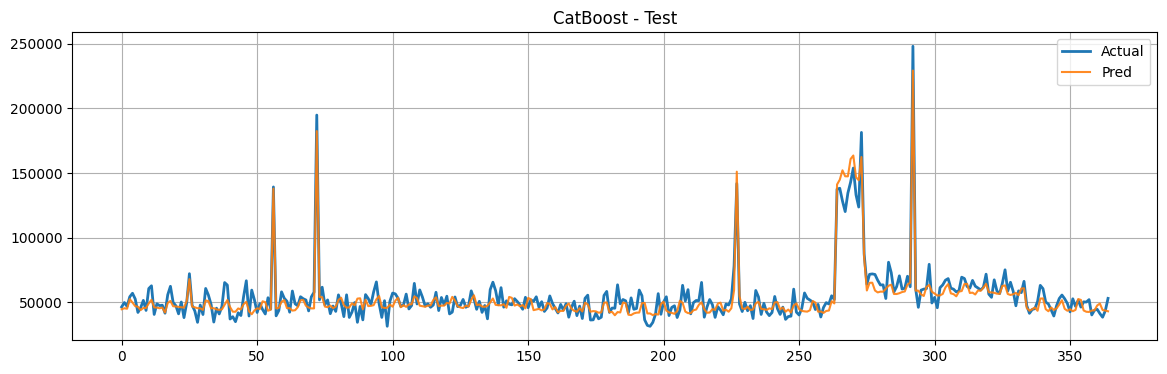

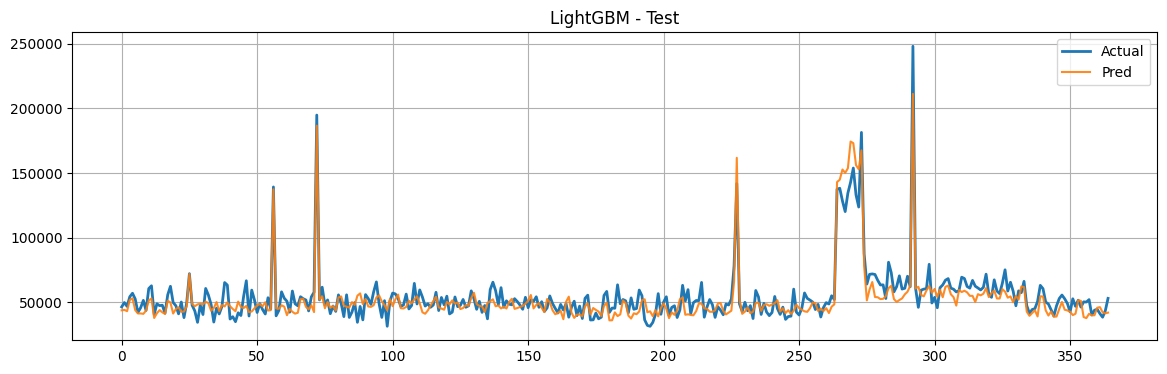

In [15]:
cat_pred = final_cat.predict(X_test)
lgb_pred = final_lgb.predict(X_test)
print("CatBoost Test metrics:", metrics_dict(y_test, cat_pred))
print("LightGBM Test metrics:", metrics_dict(y_test, lgb_pred))
plot_series("CatBoost - Test", y_test.values, cat_pred)
plot_series("LightGBM - Test", y_test.values, lgb_pred)

[LightGBM] [Warning] min_data_in_leaf is set=23, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=23
[LightGBM] [Warning] feature_fraction is set=0.6990364261577717, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6990364261577717
[LightGBM] [Warning] lambda_l1 is set=3.463151494965761, reg_alpha=0.0 will be ignored. Current value: lambda_l1=3.463151494965761
[LightGBM] [Warning] lambda_l2 is set=1.6629340870699119, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.6629340870699119
[LightGBM] [Warning] bagging_fraction is set=0.6194399565623017, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6194399565623017
Best blend weight (cat): 0.25 val RMSE: 5777.467744849293
Blended Test metrics: {'MAE': 6583.746234595723, 'RMSE': 8357.031114711388, 'R2': 0.8601138519210827}


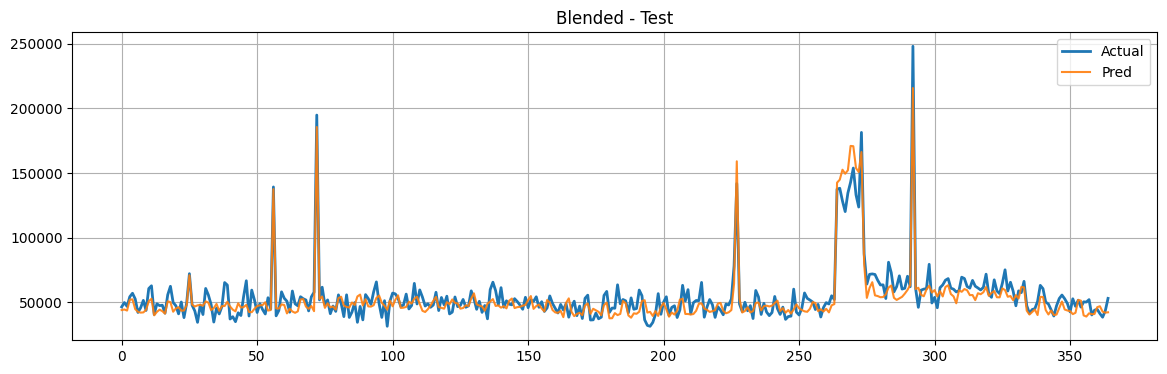

In [16]:
from sklearn.metrics import mean_squared_error
n_val = max(1, int(0.1*len(X_train)))
X_blend_tr = X_train.iloc[:-n_val]; y_blend_tr = y_train.iloc[:-n_val]
X_blend_val = X_train.iloc[-n_val:]; y_blend_val = y_train.iloc[-n_val:]
cat_val = final_cat.predict(X_blend_val)
lgb_val = final_lgb.predict(X_blend_val)
best_w, best_rmse = None, 1e12
for w in np.linspace(0,1,21):
    pred = w*cat_val + (1-w)*lgb_val
    rm = mean_squared_error(y_blend_val, pred, squared=False)
    if rm < best_rmse:
        best_rmse = rm; best_w = w
print("Best blend weight (cat):", best_w, "val RMSE:", best_rmse)
blend_pred = best_w*cat_pred + (1-best_w)*lgb_pred
print("Blended Test metrics:", metrics_dict(y_test, blend_pred))
plot_series("Blended - Test", y_test.values, blend_pred)

[LightGBM] [Warning] min_data_in_leaf is set=23, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=23
[LightGBM] [Warning] feature_fraction is set=0.6990364261577717, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6990364261577717
[LightGBM] [Warning] lambda_l1 is set=3.463151494965761, reg_alpha=0.0 will be ignored. Current value: lambda_l1=3.463151494965761
[LightGBM] [Warning] lambda_l2 is set=1.6629340870699119, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.6629340870699119
[LightGBM] [Warning] bagging_fraction is set=0.6194399565623017, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6194399565623017
[LightGBM] [Warning] min_data_in_leaf is set=23, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=23
[LightGBM] [Warning] feature_fraction is set=0.6990364261577717, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6990364261577717
[LightGBM] [Warning] lambda_l1 is se

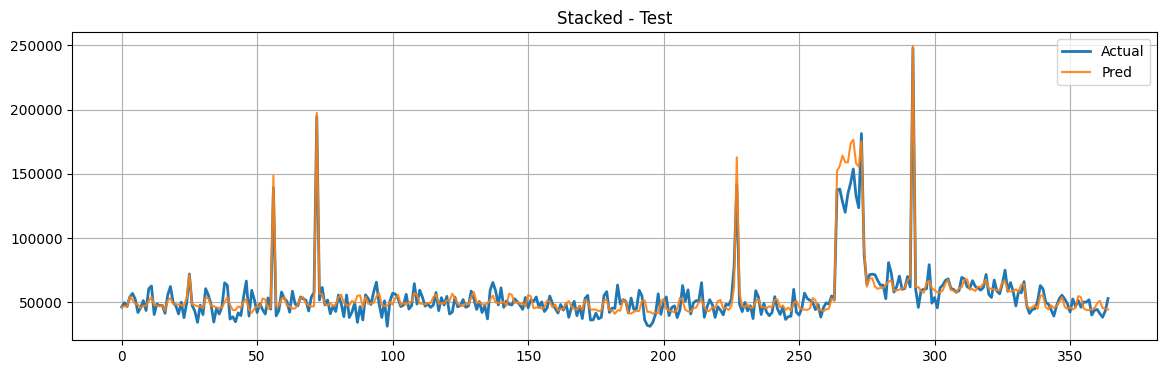

In [17]:
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
n = len(X_train)
n_folds = 5
fold_size = n // (n_folds + 1)
oof_cat = np.zeros(n)
oof_lgb = np.zeros(n)
for i in range(n_folds):
    train_end = (i+1)*fold_size
    if train_end+fold_size > n:
        break
    X_tr = X_train.iloc[:train_end]; y_tr = y_train.iloc[:train_end]
    X_val = X_train.iloc[train_end:train_end+fold_size]; y_val = y_train.iloc[train_end:train_end+fold_size]
    m_cat = CatBoostRegressor(
        iterations=int(best_cat_params.get("iterations", 1000)),
        depth=int(best_cat_params.get("depth", 6)),
        learning_rate=best_cat_params.get("learning_rate", 0.03),
        l2_leaf_reg=best_cat_params.get("l2_leaf_reg", 3.0),
        random_seed=RANDOM_SEED
    )
    m_cat.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100, verbose=False)
    oof_cat[train_end:train_end+fold_size] = m_cat.predict(X_val)
    m_l = lgb.LGBMRegressor(**best_lgb_params, n_estimators=5000) if isinstance(best_lgb_params, dict) else lgb.LGBMRegressor(n_estimators=1000)
    m_l.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], eval_metric="rmse", callbacks=[lgb.early_stopping(stopping_rounds=100)])
    oof_lgb[train_end:train_end+fold_size] = m_l.predict(X_val)
mask = oof_cat != 0
stack_X = np.column_stack([oof_cat[mask], oof_lgb[mask]])
stack_y = y_train.values[mask]
meta_model = Ridge(alpha=1.0)
meta_model.fit(stack_X, stack_y)
test_meta = np.column_stack([cat_pred, lgb_pred])
stacked_pred = meta_model.predict(test_meta)
print("Stacked Test metrics:", metrics_dict(y_test, stacked_pred))
plot_series("Stacked - Test", y_test.values, stacked_pred)

{'Blended': {'MAE': 6583.746234595723,
             'R2': 0.8601138519210827,
             'RMSE': 8357.031114711388},
 'CatBoost': {'MAE': 5868.763228609082,
              'R2': 0.889766157659798,
              'RMSE': 7418.603090741994},
 'LightGBM': {'MAE': 6905.164336244583,
              'R2': 0.8450073900904173,
              'RMSE': 8796.707653691876},
 'Stacked': {'MAE': 5789.3860143002685,
             'R2': 0.875067619034232,
             'RMSE': 7897.727988037318}}


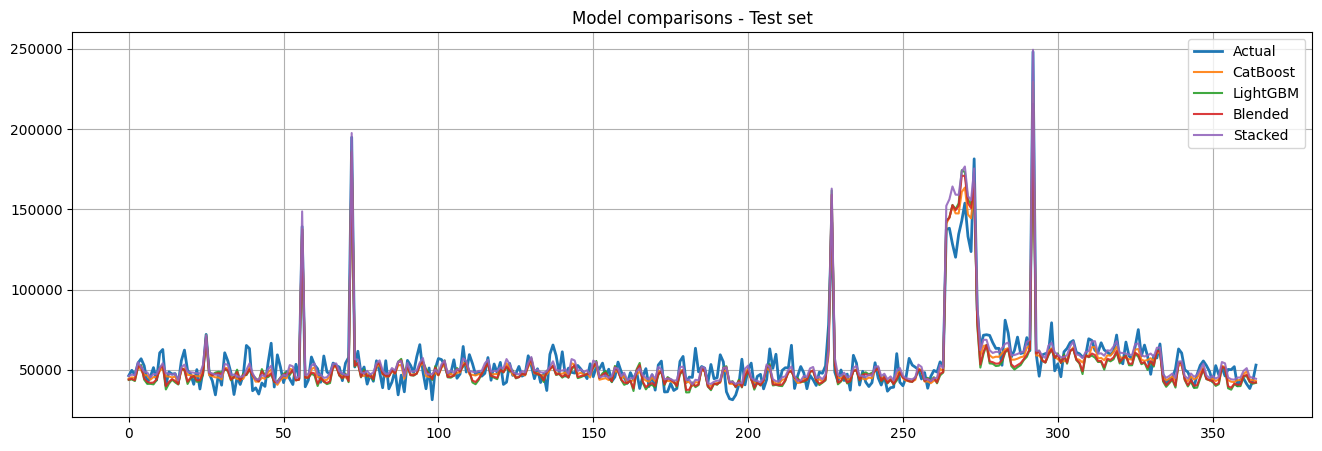


=== Diagnostics: CatBoost ===
Overall: {'MAE': 5868.763228609082, 'RMSE': 7418.603090741994, 'R2': 0.889766157659798}
Festival days: {'MAE': 14071.967279802326, 'RMSE': 15865.27038671092, 'R2': 0.776040110574948}


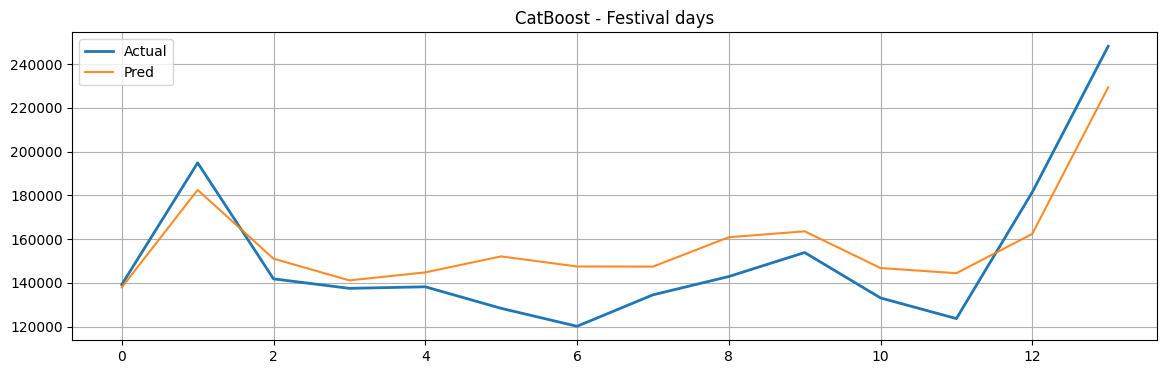

Weekend days: {'MAE': 6601.987942264039, 'RMSE': 7902.018819548773, 'R2': 0.8024813064093549}


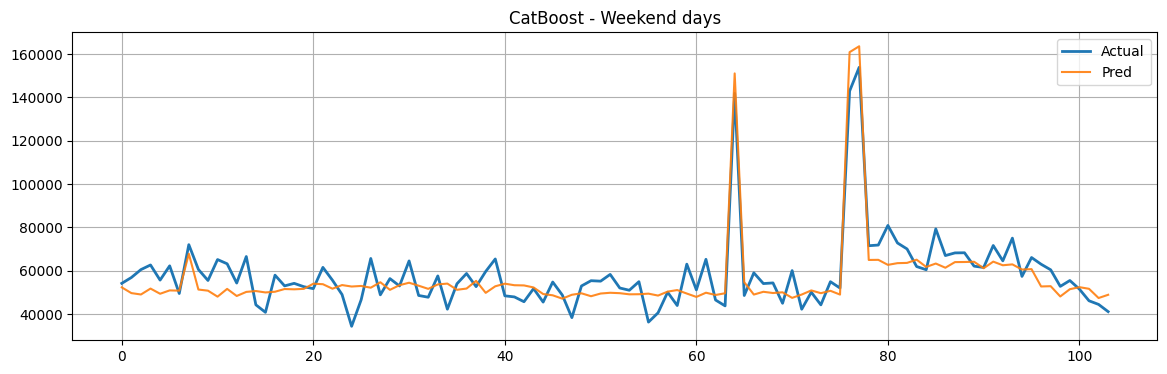

Normal days: {'MAE': 5515.634013422456, 'RMSE': 6820.555047627152, 'R2': 0.4194917380455493}

=== Diagnostics: LightGBM ===
Overall: {'MAE': 6905.164336244583, 'RMSE': 8796.707653691876, 'R2': 0.8450073900904173}
Festival days: {'MAE': 19246.55538842591, 'RMSE': 21881.63814932591, 'R2': 0.573975130376061}


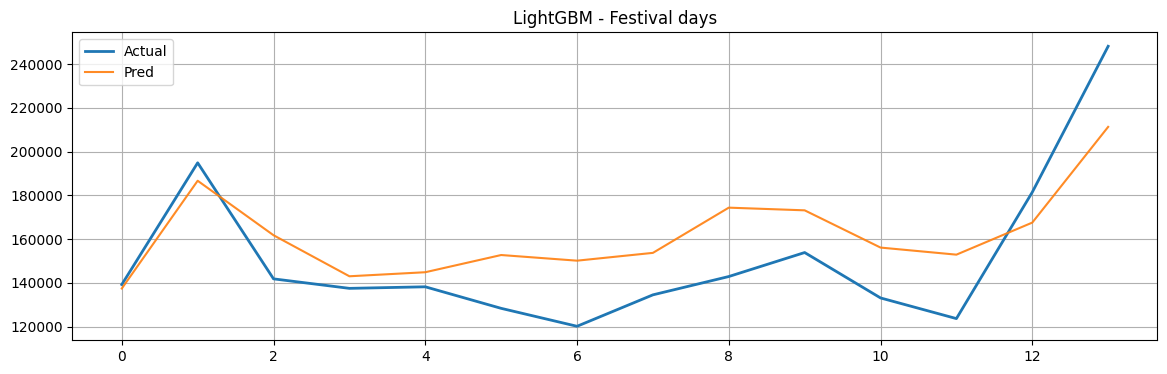

Weekend days: {'MAE': 7411.077058313934, 'RMSE': 9297.826853645349, 'R2': 0.7265392542000544}


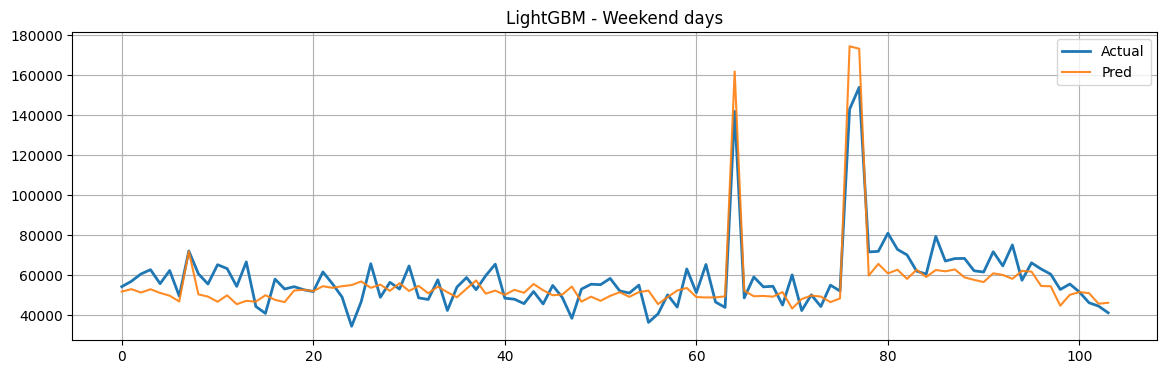

Normal days: {'MAE': 6406.325474942312, 'RMSE': 7825.30870037765, 'R2': 0.23586177298425037}

=== Diagnostics: Blended ===
Overall: {'MAE': 6583.746234595723, 'RMSE': 8357.031114711388, 'R2': 0.8601138519210827}
Festival days: {'MAE': 17952.908361270016, 'RMSE': 20224.530629540754, 'R2': 0.6360579886355255}


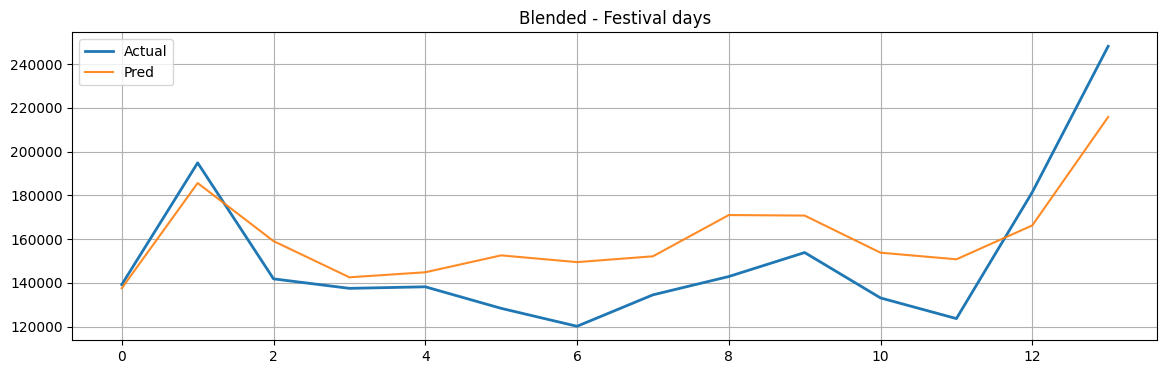

Weekend days: {'MAE': 7173.017335359625, 'RMSE': 8865.555713727234, 'R2': 0.7513754489615364}


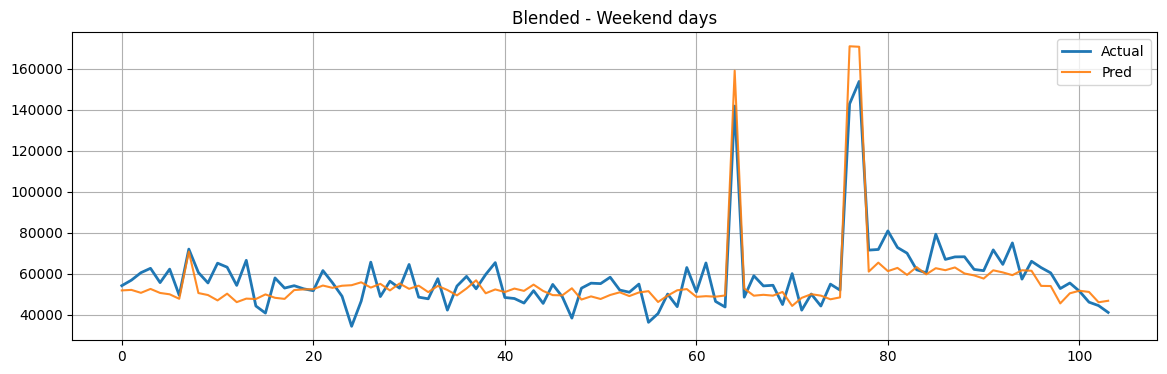

Normal days: {'MAE': 6118.290523268972, 'RMSE': 7489.012912374704, 'R2': 0.3001287925538414}

=== Diagnostics: Stacked ===
Overall: {'MAE': 5789.3860143002685, 'RMSE': 7897.727988037318, 'R2': 0.875067619034232}
Festival days: {'MAE': 20230.062274015876, 'RMSE': 23370.682880418004, 'R2': 0.5140203395713366}


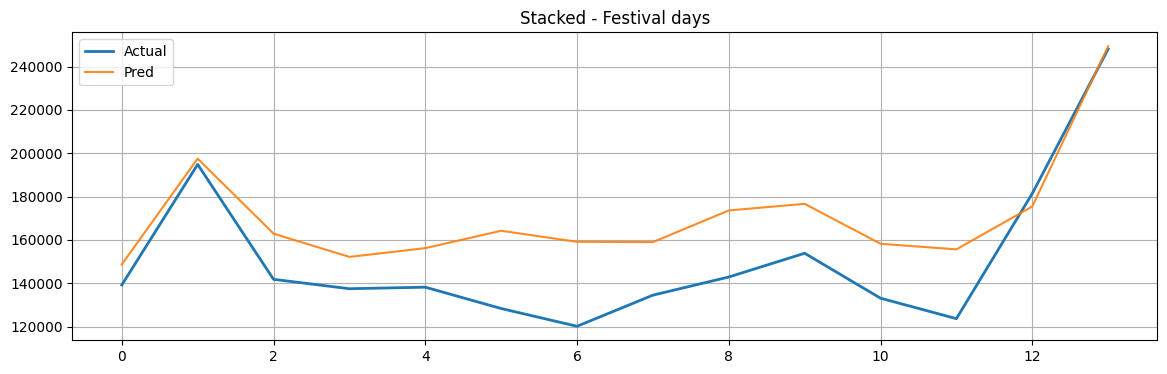

Weekend days: {'MAE': 6471.877025341847, 'RMSE': 8323.338567000415, 'R2': 0.7808571998981769}


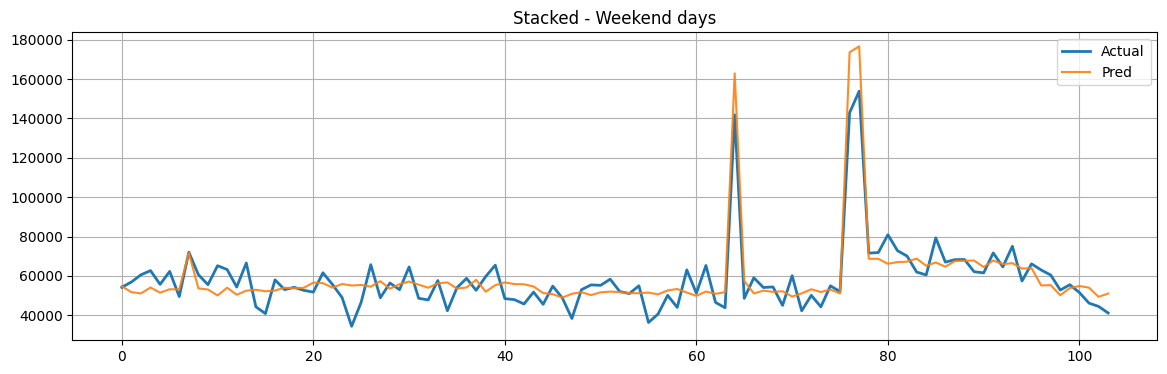

Normal days: {'MAE': 5203.542390267368, 'RMSE': 6535.228564438771, 'R2': 0.4670450123540847}


In [18]:
results = {
    "CatBoost": metrics_dict(y_test, cat_pred),
    "LightGBM": metrics_dict(y_test, lgb_pred),
    "Blended": metrics_dict(y_test, blend_pred),
    "Stacked": metrics_dict(y_test, stacked_pred)
}
pprint.pprint(results)
plt.figure(figsize=(16,5))
plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(cat_pred, label='CatBoost', alpha=0.9)
plt.plot(lgb_pred, label='LightGBM', alpha=0.9)
plt.plot(blend_pred, label='Blended', alpha=0.9)
plt.plot(stacked_pred, label='Stacked', alpha=0.9)
plt.legend(); plt.title("Model comparisons - Test set"); plt.grid(True); plt.show()
model_diagnostics("CatBoost", y_test.values, cat_pred, test_df)
model_diagnostics("LightGBM", y_test.values, lgb_pred, test_df)
model_diagnostics("Blended", y_test.values, blend_pred, test_df)
model_diagnostics("Stacked", y_test.values, stacked_pred, test_df)

In [19]:
blended_model = {
    "cat": final_cat,
    "lgb": final_lgb,
    "weight": best_w
}
joblib.dump(blended_model, "saved_models/blended_model.pkl")
joblib.dump(scaler, "saved_models/scaler.pkl")
print("Saved blended model and scaler successfully!")

Saved blended model and scaler successfully!


In [20]:
def blended_predict(blended_dict, X):
    w = blended_dict["weight"]
    cat_pred = blended_dict["cat"].predict(X)
    lgb_pred = blended_dict["lgb"].predict(X)
    return w*cat_pred + (1-w)*lgb_pred

In [21]:
def feature_engineering_for_user(raw_input, df_hist):
    df = df_hist.copy()
    user_row = pd.DataFrame([raw_input])
    user_row["date"] = pd.to_datetime(user_row["date"])
    df = pd.concat([df, user_row], ignore_index=True)
    TARGET = "visitor_count"
    df["day_of_week"] = df["date"].dt.weekday
    df["month"] = df["date"].dt.month
    df["day_of_year"] = df["date"].dt.dayofyear
    df["year"] = df["date"].dt.year
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["sin_dow"] = np.sin(2*np.pi * df["day_of_week"]/7)
    df["cos_dow"] = np.cos(2*np.pi * df["day_of_week"]/7)
    df["sin_month"] = np.sin(2*np.pi * df["month"]/12)
    df["cos_month"] = np.cos(2*np.pi * df["month"]/12)
    df["sin_year"] = np.sin(2*np.pi * df["day_of_year"]/365.25)
    df["cos_year"] = np.cos(2*np.pi * df["day_of_year"]/365.25)
    for lag in [1,2,3,7,14,30,60]:
        df[f"lag_{lag}"] = df[TARGET].shift(lag)
    for win in [7,14,30]:
        df[f"roll_mean_{win}"] = df[TARGET].shift(1).rolling(win).mean()
        df[f"roll_std_{win}"] = df[TARGET].shift(1).rolling(win).std()
    df["ema_7"] = df[TARGET].shift(1).ewm(span=7).mean()
    df["ema_30"] = df[TARGET].shift(1).ewm(span=30).mean()
    df = df.fillna(method="ffill").fillna(0)
    return df.iloc[-1:].copy()

In [22]:
def predict_from_user():
    print("\nEnter the following details:\n")
    raw = {}
    raw["date"] = input("Date (YYYY-MM-DD): ").strip()
    raw["temple_name"] = "Ambaji"
    raw["day_of_week"] = int(input("Day of week (0=Mon ... 6=Sun): "))
    raw["is_weekend"] = int(input("Is weekend? (0/1): "))
    print("\nFestival options:")
    print(" 0 = None")
    print(" 1 = Diwali")
    print(" 2 = Holi")
    print(" 3 = Janmashtami")
    print(" 4 = Makar Sakranti")
    print(" 5 = MahaShivratri")
    print(" 6 = Navratri")
    fest_code = int(input("Enter festival code (0–6): "))
    if fest_code not in [0,1,2,3,4,5,6]:
        fest_code = 0  # default to None if invalid
    raw["festival_name"] = fest_code
    raw["public_holiday"] = int(input("Public holiday? (0/1): "))
    raw["temp_avg_c"] = float(input("Temperature avg (°C): "))
    raw["precipitation_mm"] = float(input("Rainfall (mm): "))
    df_hist = pd.read_csv("test_clean_encoded_2.csv")
    df_hist["date"] = pd.to_datetime(df_hist["date"])
    raw["temple_name"] = 0  
    raw_row = pd.DataFrame([raw])
    raw_row["date"] = pd.to_datetime(raw_row["date"])
    df_ext = pd.concat([df_hist, raw_row], ignore_index=True)
    for lag in [1,2,3,7,14,30,60]:
        df_ext[f"lag_{lag}"] = df_ext["visitor_count"].shift(lag)
    for win in [7,14,30]:
        df_ext[f"roll_mean_{win}"] = df_ext["visitor_count"].shift(1).rolling(win).mean()
        df_ext[f"roll_std_{win}"]  = df_ext["visitor_count"].shift(1).rolling(win).std()
    df_ext["ema_7"]  = df_ext["visitor_count"].shift(1).ewm(span=7).mean()
    df_ext["ema_30"] = df_ext["visitor_count"].shift(1).ewm(span=30).mean()
    df_ext["month"] = df_ext["date"].dt.month
    df_ext["day_of_year"] = df_ext["date"].dt.dayofyear
    df_ext["year"] = df_ext["date"].dt.year
    df_ext["weekofyear"] = df_ext["date"].dt.isocalendar().week.astype(int)
    df_ext["sin_dow"]   = np.sin(2*np.pi * df_ext["day_of_week"]/7)
    df_ext["cos_dow"]   = np.cos(2*np.pi * df_ext["day_of_week"]/7)
    df_ext["sin_month"] = np.sin(2*np.pi * df_ext["month"]/12)
    df_ext["cos_month"] = np.cos(2*np.pi * df_ext["month"]/12)
    df_ext["sin_year"]  = np.sin(2*np.pi * df_ext["day_of_year"]/365.25)
    df_ext["cos_year"]  = np.cos(2*np.pi * df_ext["day_of_year"]/365.25)
    user_fe = df_ext.iloc[-1:].copy()
    user_fe = user_fe.fillna(method="ffill").fillna(0)
    X = user_fe[feature_cols].copy()
    scaler = joblib.load("saved_models/scaler.pkl")
    X[num_cols] = scaler.transform(X[num_cols])
    blend = joblib.load("saved_models/blended_model.pkl")
    pred = blended_predict(blend, X)[0]
    print("Predicted Visitor Count =", int(pred))
    return pred

In [ ]:
predict_from_user()


Enter the following details:



In [ ]:
predict_from_user()

In [ ]:
predict_from_user()